In [ ]:
#READ ME!!!!!!!
#I was in charge of pre-processing the Chrons Disease Data Set as well as in charge of visual analysis graphs
#This Code includes three things 1) CD preprocessing steps; 2) volcano plots for CD and UC; 3) heatmaps displaying significant DEGs from volcano plot

In [ ]:
#=======================================================================================================================

In [ ]:
#1) PRE-PROCESSING CODE
#goal: put all teh CD samples into one data set
#------------------

#GSM6732256.csv.gz = GSM6732256 CD134-2 
#GSM6732257.csv.gz = GSM6732257 CD139
#GSM6732259.csv.gz = GSM6732259 CD293 = 	CD293
#GSM6732262.csv.gz = GSM6732262 CD303


In [ ]:
import numpy as np
import pandas as pd
import json

In [ ]:
#unzip the files because I was not able to unzip them for some reason
#for this I utilized ChatGPT AI to help give me the code to unzip it
filename = 'GSM6732256.csv.gz'
import gzip

with gzip.open(filename, "rt") as f:
    for i in range (10):
        print (i, f.readline()[:500])

In [ ]:
#labeled each Chrons Disease sample as a different file path 
file_path_1 = 'GSM6732256.csv.gz'
file_path_2 = 'GSM6732257.csv.gz'
file_path_3 = 'GSM6732259.csv.gz'
file_path_4 = 'GSM6732262.csv.gz'

# Skip the first 6 lines (1st 6 rows was the issue why I could not unzip it) and unzip data
#I set the index afterwards because when you manipulate and concat different df with indices it overwrites cell_index
CD_df_1 = pd.read_csv(file_path_1, compression='gzip', skiprows=6)
CD_df_2 = pd.read_csv(file_path_2, compression='gzip', skiprows=6)
CD_df_3 = pd.read_csv(file_path_3, compression='gzip', skiprows=6)
CD_df_4 = pd.read_csv(file_path_4, compression='gzip', skiprows=6)

#goal: stack the four data frames vertical, add sample columns, condition columns, then set indicex to cell_index

In [ ]:
# Display the data
#only run code once --> 
CD_df_1.insert(0, 'Sample', 'CD134-2')
#if you need to make a spelling correction; must delete column then make new one --> df = df.drop('column_name', axis=1)
print(CD_df_1.shape)
CD_df_1.head()

In [ ]:
# Display the data
#only run code once --> 
CD_df_2.insert(0, 'Sample', 'CD139')
print(CD_df_2.shape)
CD_df_2.head()


In [ ]:
# Display the data
#only run code once --> 
CD_df_3.insert(0, 'Sample', 'CD293')
print(CD_df_3.shape)
CD_df_3.head()

In [ ]:
# Display the data
#only run code once --> 
CD_df_4.insert(0, 'Sample', 'CD303')
print(CD_df_4.shape)
CD_df_4.head()

In [ ]:
# stack data frame CD1 and CD2
CD_df_1_2 = pd.concat([CD_df_1, CD_df_2])
CD_df_1_2.shape

In [ ]:
# stack data frame CD3 and CD4
CD_df_3_4 = pd.concat([CD_df_3, CD_df_4])
CD_df_3_4.shape

In [ ]:
# stack data frame CD1_2 and CD3_4
CD_df = pd.concat([CD_df_1_2, CD_df_3_4])
CD_df.shape

In [ ]:
#check for any N/A values
CD_df.isna().sum().sum()

In [ ]:
#only run code once --> inserts column called condition adds a column
CD_df.insert(0, 'Condition', 'Chrons_Disease')

In [ ]:
CD_df.head()

In [ ]:
CD_df.shape

In [ ]:
CD_df.to_csv('CD_dataframe.csv', index = False)
#make intto a csv file

In [ ]:
#read it in using index columns = 'Cell_Index'
CD_dataframe = pd.read_csv('CD_dataframe.csv', index_col= 'Cell_Index')
CD_dataframe.head()

In [ ]:
CD_df.shape

In [ ]:
#=======================================================================================================================

In [ ]:
#2) VOLCANO PLOTS FOR CD AND UC

In [2]:
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

In [3]:
#dataset we have is called UC_CK_CD
df = pd.read_csv('UC_CK_CD.csv', index_col='Cell_Index')

#first column had weird empty numbers so we dropped it when loading it in and made the "cell_index" col the index
df = df.drop(df.columns[0], axis=1)
df.head()

,Condition,Sample,CD103|ITGAE|AHS0001|pAbO,CD127|IL7R|AHS0028|pAbO,CD161:DX12|KLRB1|AHS0002|pAbO,CD195:2D7|CCR5|AHS0070|pAbO,CD197|CCR7|AHS0007|pAbO,CD27:M-T271|CD27|AHS0025|pAbO,CD3:SK7|CD3E|AHS0033|pAbO,CD45RA:HI100|PTPRC|AHS0009|pAbO,...,VPREB3|NM_013378.2|Reference_end,VPS28|NM_016208.3|Reference_end,VSIG4|NM_007268.2|Reference_end,XBP1|NM_005080.3|Reference_end,XCL1|NM_002995.2|Reference_end,YBX3|NM_003651.4|Reference_end,ZAP70|NM_001079.3|Reference_end,ZBED2|NM_024508.4|Reference_end,ZBTB16|NM_006006.4|Reference_end,ZNF683|NM_173574.3|Reference_end
Cell_Index,,,,,,,,,,,,,,,,,,,,,
707743,Control_samples,CK118,12,23,4,23,12,34,37,3,...,0,2,0,30,0,0,0,0,0,0
577396,Control_samples,CK118,12,21,11,14,16,2710,290,35,...,2,0,0,30,0,0,0,0,0,0
89979,Control_samples,CK118,17,18,6,21,7,463,30,1,...,0,1,0,18,0,3,0,0,0,0
57379,Control_samples,CK118,13,11,5,16,5,11,32,3,...,0,0,0,34,0,0,0,0,0,0
658439,Control_samples,CK118,6,17,4,3,5,2031,51,3,...,1,2,0,30,0,0,0,0,0,0


In [4]:
#the genes start in row 3 index [2] so we split data into metadata and gene df
metadata = df.iloc[:, :2]
gene = df.iloc[:, 2:]

In [5]:
#genes have a hard to interpret label
#code so names only display first and last sub string before the first | and after the last |
#ex.  CD103|ITGAE|AHS0001|pAbO --> CD103|pAbO
gene.columns = gene.columns.str.split('|').str[0] + '|' + gene.columns.str.split('|').str[-1]

In [6]:
#sum all gene counts horizontally (tells us gene express total)
cell_sums = gene.sum(axis=1)
# divide each original gene counts by total cell count to yield proportion of DNA each gene makes up in a cell
#multiply by a 1,000,000 --> count per mmillion
cpm_matrix = gene.div(cell_sums, axis=0) * 1000000
#log transform matrix so that we get 10^n
#for genes with 0 expression add 1 so that 10^x = 1 and x = 0
log2_counts = np.log2(cpm_matrix + 1)

In [7]:
#look at the rows in the first column
group_labels = df.iloc[:, 0] 
#group all rows by condition
df_control = log2_counts[group_labels == 'Control_samples']
df_CD = log2_counts[group_labels == 'Chrons_Disease']
df_UC = log2_counts[group_labels == 'Ulcerative_colitis']

In [8]:
#initilize df used for plotting
plot_df = pd.DataFrame(index=gene.columns)

In [9]:
#Chron v Control X axis coordinates

#calculate mean for eahc column in control data frame 
#--> average mean expression of gene x in the control group
mean_control = df_control.mean(axis=0)

#calculate mean in each col. in chrons disease data frame
#--> average mean expression of gene x in the chrons disease group
mean_CD = df_CD.mean(axis=0)

#creates a new col in plot_df that has the values for mean_CD - mean_control
    #remember data is already log transformed! Log2A-log2B=log2(A/B)
plot_df['log2FC_CD'] = mean_CD - mean_control
    #CD is smaller than control --> get #<1 --> since 10^-x<1 result is negative --> less expressed in CD compared to control
    #CD is larger than control --> get #>1 --> since 10^x>1 result is pos -->more expressed in CD compared to control
    #Cd = control --> = 1 --> 10^0=1 --> 0 difference in gene expression

In [40]:
#Chron v Control Y axis coordinates

#stats.ttest_ind returns test statistic as well as p value --> -, only retruns p val
#axis = 0 --> preform across each col (genes) for all samples
_, pvals_CD = stats.ttest_ind(df_CD, df_control, axis=0, equal_var=False)

#maps p val to a panda series using gene names
pvals_series = pd.Series(pvals_CD, index=gene.columns).fillna(1.0)

#shifts p vals --> -10 log and stores it in the plot df
#ANY NUMBER THAT HAS A P VAL OF ALMOST 0 --> pval 300
plot_df['neg_log_pval_CD'] = -np.log10(pvals_series + 1e-300)

In [41]:
print(df_CD.shape)
print(df_control.shape)

(27779, 432)
(25171, 432)


In [42]:
df_CD.head()

,CD103|pAbO,CD127|pAbO,CD161:DX12|pAbO,CD195:2D7|pAbO,CD197|pAbO,CD27:M-T271|pAbO,CD3:SK7|pAbO,CD45RA:HI100|pAbO,CD45RO|pAbO,CD4:SK3|pAbO,...,VPREB3|Reference_end,VPS28|Reference_end,VSIG4|Reference_end,XBP1|Reference_end,XCL1|Reference_end,YBX3|Reference_end,ZAP70|Reference_end,ZBED2|Reference_end,ZBTB16|Reference_end,ZNF683|Reference_end
Cell_Index,,,,,,,,,,,,,,,,,,,,,
574286,10.942738,10.798426,10.194775,7.877763,10.638056,13.984405,13.025594,10.010519,10.074588,13.057652,...,0.000000,5.580164,0.0,12.344381,0.0,0.0,0.0,0.0,0.0,0.0
612047,11.578823,10.556227,10.061854,9.509943,10.646366,12.634722,13.230579,9.690282,10.460077,13.549559,...,5.630492,6.615857,0.0,9.772647,0.0,0.0,0.0,0.0,0.0,0.0
771787,10.666652,9.713288,10.034872,8.038992,9.036247,16.753240,12.398336,11.355975,9.414124,12.557298,...,0.000000,0.000000,0.0,10.356525,0.0,0.0,0.0,0.0,0.0,0.0
379330,10.613476,10.982502,10.488029,8.616236,10.488029,14.700072,13.005048,10.028974,10.198746,13.005048,...,0.000000,0.000000,0.0,11.072657,0.0,0.0,0.0,0.0,0.0,0.0
583269,11.026813,10.290308,10.631103,8.386582,10.383346,13.532134,13.040648,10.705058,10.470745,13.227906,...,0.000000,0.000000,0.0,10.906579,0.0,0.0,0.0,0.0,0.0,0.0


In [43]:
#Colitis V COntrol Log X axis coordinates

#calculate mean for each column in Ulcerative colitis data frame 
#yields average mean gene expression in UC group
mean_UC = df_UC.mean(axis=0)


#creates a new col called 'log2FC_UC' in plot_df that has the values for mean_UC - mean_control
plot_df['log2FC_UC'] = mean_UC - mean_control
#decimal<1 --> negative down regulation
#number>1 --> positive up regulation
#number=1 --> no diff

In [44]:
#Colitis V COntrol P val Y axis coordinates
_, pvals_UC = stats.ttest_ind(df_UC, df_control, axis=0, equal_var=False)

#maps p vals to gene name in UC
pvals_series_UC = pd.Series(pvals_UC, index=gene.columns).fillna(1.0)

#transform p-values into log based 10 and insert into DF
plot_df['neg_log_pval_UC'] = -np.log10(pvals_series_UC + 1e-300)

In [45]:
#set threshold to log (2) -> log (.5)
fc_threshold = 2.0 

#transforms p val threshold to log
pval_threshold = -np.log10(0.0001) 

In [46]:
# Crohn Genes orginization: up/down/not sig
#baseline sets everyhting to not sig
plot_df['Color_CD'] = 'Not Significant'

#up regulated overwites 'not singificant' with upregulated if conditions are met
#log2 fold change must be greater! than negative threshold AND negative log10 p-value must be greater than significance threshold
plot_df.loc[(plot_df['log2FC_CD'] > fc_threshold) & (plot_df['neg_log_pval_CD'] > pval_threshold), 'Color_CD'] = 'Upregulated'

#down regulated overwites 'not singificant' with down regulated if conditions are met
#log2 fold change must be less! than negative threshold AND n1egative log10 p-value must be greater than significance threshold
plot_df.loc[(plot_df['log2FC_CD'] < -fc_threshold) & (plot_df['neg_log_pval_CD'] > pval_threshold), 'Color_CD'] = 'Downregulated'

In [47]:
# Colitis Genes orginization: up/down/not sig
#baseline sets everyhting to not sig
plot_df['Color_UC'] = 'Not Significant'

#up regulated overwites 'not singificant' with upregulated if conditions are met
#log2 fold change must be greater! than negative threshold AND negative log10 p-value must be greater than significance threshold
plot_df.loc[(plot_df['log2FC_UC'] > fc_threshold) & (plot_df['neg_log_pval_UC'] > pval_threshold), 'Color_UC'] = 'Upregulated'

#down regulated overwites 'not singificant' with down regulated if conditions are met
#log2 fold change must be less! than negative threshold AND n1egative log10 p-value must be greater than significance threshold
plot_df.loc[(plot_df['log2FC_UC'] < -fc_threshold) & (plot_df['neg_log_pval_UC'] > pval_threshold), 'Color_UC'] = 'Downregulated'

In [48]:
#color coding up:red, down:blue, not sig: grey
color_map = {'Upregulated': 'red','Downregulated': 'blue','Not Significant': 'lightgray'}

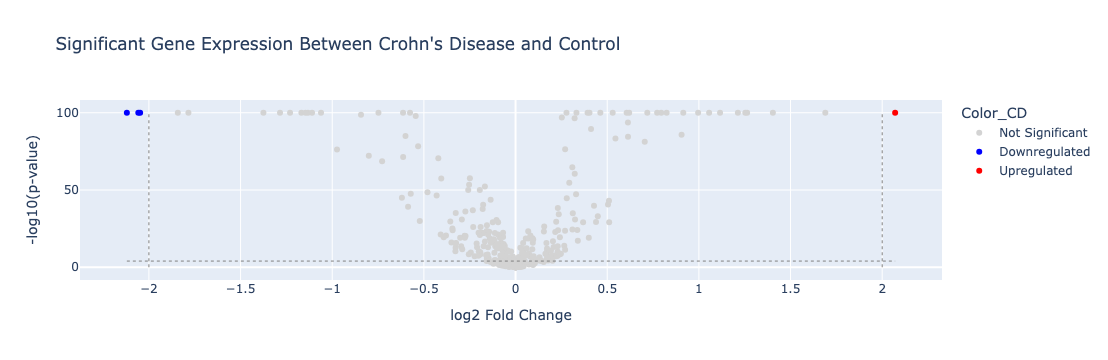

In [49]:
#==============================Chrons Disease versus control volcano plot==============================
#using plotly.express package (px)
#params--> (datd df used, x axis = log2FC_CD, y axis = neg_log_pval_CD, color codes based on up and down regulated, color dictionary, name appears when mouse hovers over, title of plot)
fig_cd = px.scatter(plot_df, x='log2FC_CD', y='neg_log_pval_CD', color='Color_CD',color_discrete_map=color_map,hover_name=plot_df.index,title="Significant Gene Expression Between Crohn's Disease and Control")

#code for ~professional~ formatting layout 
#params-->(define x axis title,define y axis title)
fig_cd.update_layout(xaxis_title='log2 Fold Change', yaxis_title='-log10(p-value)',shapes=[

    #param--> (draws line across for horizontally, from min calculated log2FC_CD, to max calculated log2FC_CD,y0 = y1 --> flat line at pval threshold, grey dotted line w/ width 1 )
    dict(type='line', x0=plot_df['log2FC_CD'].min(), x1=plot_df['log2FC_CD'].max(), y0=pval_threshold, y1=pval_threshold, line=dict(color='gray', dash='dot', width=1)),
   
    #draws veritcal line on the right at pos. fc_threshold from the bottom y0 --> top y1 max of neg_log_pval_CD with a grey dotted line)
    dict(type='line', x0=fc_threshold, x1=fc_threshold, y0=0, y1=plot_df['neg_log_pval_CD'].max(), line=dict(color='gray', dash='dot', width=1)),

    
    #draws veritcal line on the left at neg. fc_threshold from the bottom y0 --> top y1 max of neg_log_pval_CD with a grey dotted line)
    dict(type='line', x0=-fc_threshold, x1=-fc_threshold, y0=0, y1=plot_df['neg_log_pval_CD'].max(), line=dict(color='gray', dash='dot', width=1))])

fig_cd.show()

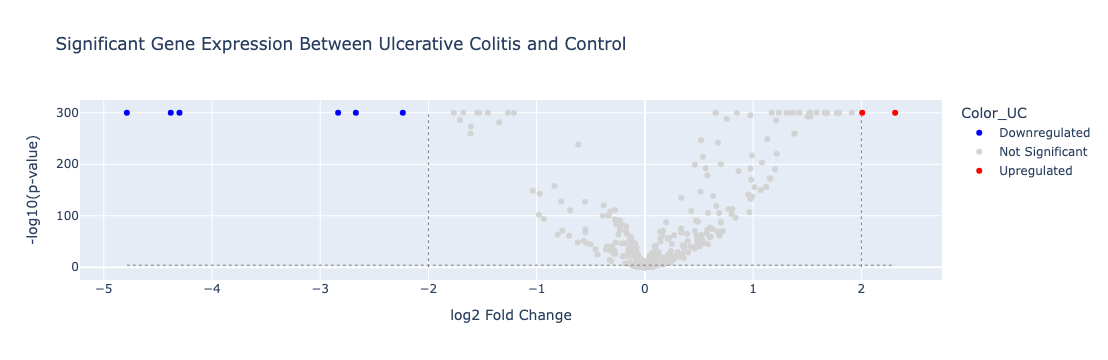

In [25]:
#==============================Colitis versus control==============================
#using plotly.express package (px)
#params--> (data df used, x axis = log2FC_UC, y axis = neg_log_pval_UC, color codes based on up and down regulated, color dictionary, name appears when mouse hovers over, title of plot)
fig_uc = px.scatter(plot_df, x='log2FC_UC', y='neg_log_pval_UC', color='Color_UC',color_discrete_map=color_map,hover_name=plot_df.index,title="Significant Gene Expression Between Ulcerative Colitis and Control")

#code for ~professional~ formatting layout 
#params-->(define x axis title,define y axis title)
fig_uc.update_layout(xaxis_title='log2 Fold Change', yaxis_title='-log10(p-value)',shapes=[

        #param--> (draws line across for horizontally, from min calculated log2FC_UC, to max calculated log2FC_UC,y0 = y1 --> flat line at pval threshold, y1= 2nd line, grey dotted line w/ width 1 )
        dict(type='line', x0=plot_df['log2FC_UC'].min(), x1=plot_df['log2FC_UC'].max(), y0=pval_threshold, y1=pval_threshold, line=dict(color='gray', dash='dot', width=1)),

        #draws veritcal line on the right at pos. fc_threshold from the bottom y0 --> top y1 max of neg_log_pval_UC with a grey dotted line)
        dict(type='line', x0=fc_threshold, x1=fc_threshold, y0=0, y1=plot_df['neg_log_pval_UC'].max(), line=dict(color='gray', dash='dot', width=1)),

        #draws veritcal line on the left at neg. fc_threshold from the bottom y0 --> top y1 max of neg_log_pval_UC with a grey dotted line)
        dict(type='line', x0=-fc_threshold, x1=-fc_threshold, y0=0, y1=plot_df['neg_log_pval_UC'].max(), line=dict(color='gray', dash='dot', width=1))])

fig_uc.show()

In [26]:
#save as interactive version volcano plt
fig_uc.write_html("volcano_plot_colitis.html")
fig_cd.write_html("volcano_plot_crohns.html")

#save as png version of volcano plot
fig_uc.write_image("volcano_plot_colitis.png", scale=2)
fig_cd.write_image("volcano_plot_crohns.png", scale=2)

In [35]:
plot_df[['neg_log_pval_CD']].describe()

,neg_log_pval_CD
count,432.000000
mean,29.826930
std,59.012723
min,-0.000000
25%,1.551668
50%,7.142790
75%,23.157852
max,300.000000


In [37]:
plot_df.head()

,log2FC_CD,neg_log_pval_CD,log2FC_UC,neg_log_pval_UC,Color_CD,Color_UC
CD103|pAbO,-1.168214,128.620284,-4.380840,300.0,Not Significant,Downregulated
CD127|pAbO,-1.109918,300.000000,-2.834451,300.0,Not Significant,Downregulated
CD161:DX12|pAbO,-1.132425,248.577644,-4.786668,300.0,Not Significant,Downregulated
CD195:2D7|pAbO,-1.784438,300.000000,-4.300480,300.0,Not Significant,Downregulated
CD197|pAbO,-1.230073,300.000000,-2.237209,300.0,Not Significant,Downregulated


In [27]:
#=======================================================================================================================

In [28]:
#3) HEAT MAP USING SIGNIFICANT DEG

In [29]:
#goal: make a list of sig genes to incorperate into heat map
#make list with sig genes (all the genes in df that are not =  "not sig") or .ne()
all_sig_genes = plot_df[plot_df['Color_CD'].ne('Not Significant') | plot_df['Color_UC'].ne('Not Significant')].index.tolist()

#use list for heat map
print(all_sig_genes)

['CD103|pAbO', 'CD127|pAbO', 'CD161:DX12|pAbO', 'CD195:2D7|pAbO', 'CD197|pAbO', 'CD45RA:HI100|pAbO', 'CCL5|Reference_end', 'CTLA4|Reference_end', 'CXCL13|Reference_end', 'NR4A2|PolyA_1', 'NR4A2|Reference_end', 'PIK3IP1|Reference_end']


In [22]:
all_sig_genes = [# Crohn's
                 'NR4A2|Reference_end', 'NR4A2|PolyA_1', 'CD45RA:HI100|pAbO', 'PIK3IP1|Reference_end', 
                 # Colitis
                 'CD103|pAbO', 'CD127|pAbO', 'CD161:DX12|pAbO', 'CD195:2D7|pAbO', 'CD197|pAbO', 'CCL5|Reference_end', 'CTLA4|Reference_end', 'CXCL13|Reference_end']

In [23]:
#sig genes are now called heatmap genes
heatmap_genes = all_sig_genes

#looks at the log2fold expression counts and takes only genes that are significant/in the heatmap gene list
heatmap_data = log2_counts[heatmap_genes].copy()

#organizes heat map genes for expression of control grp, corhns group CD, colitis group UC
heatmap_data['Group'] = group_labels

In [24]:
#Displaying group means in heat map
#have 85000+ samples --> condenses all individual sample rows into a single row calculating average of samples (by group)
group_means = heatmap_data.groupby('Group').mean()

In [25]:
#control as the baseline for expression: standard noy up or down reg
control_baseline = group_means.loc['Control_samples']

#subtract baseline fromevery row in the group means col by col to yield proportion --> log2(disease/control)
fc_matrix = group_means.sub(control_baseline, axis=1)

In [26]:
#specify the order I want the heatmap to display groups in 
group_order = ['Chrons_Disease', 'Control_samples', 'Ulcerative_colitis']

#reindexes the  index so that they are grouped in order of Chrons 1st, Control 2nd, Colitis 3rd
fc_matrix = fc_matrix.reindex(group_order)

NameError: name 'plt' is not defined

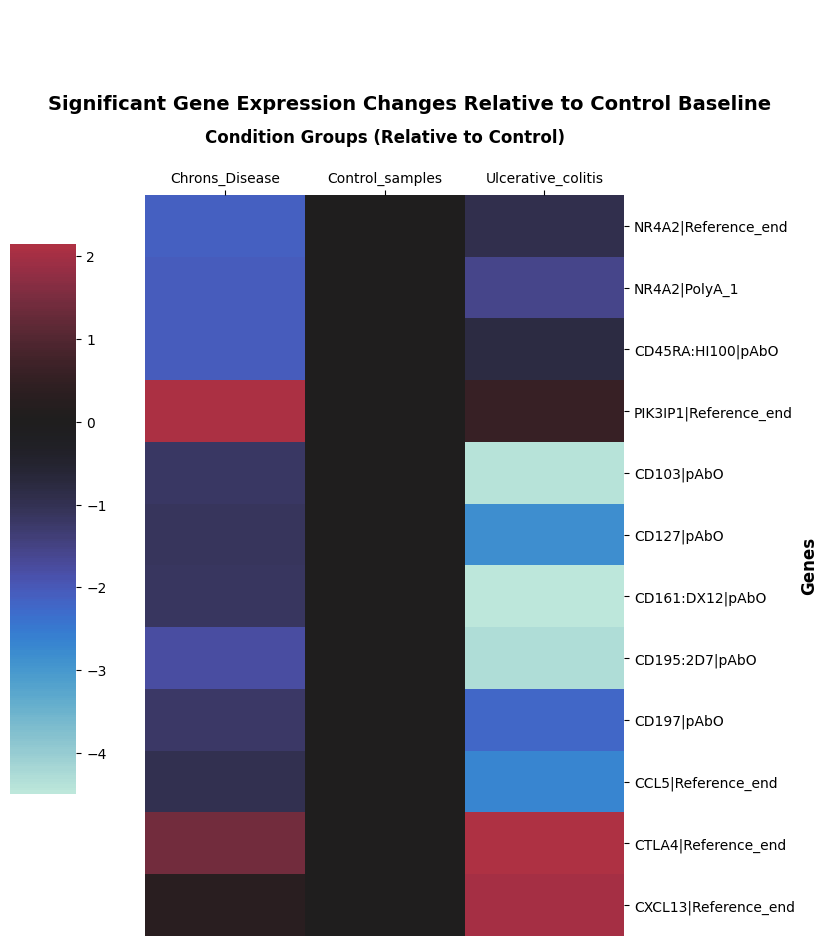

In [27]:
#==============================Significant Differntially Expressed Genes HEATMAP==============================
#plot graph using seaborn library; clustermap--> heatmap
#params --> (fc_matrix.T --> use fc_matrix as our df and .T--> switch rows and columns *for aesthetic purposes*, cmap --> color scheme...
#center-->where to anchor center for color scheme, robust calc. color bounds so that outliers dont skew color, rowcluster/col cluster turns off heirarchal
#cclustering trees *did for aesthetics*, size of figure, show tick labels)
g = sns.clustermap(fc_matrix.T,cmap='icefire',center=0,robust=True,row_cluster=False,col_cluster=False,figsize=(8, 10), yticklabels=True)

#includes group labels (Control, Chrons, Colitis) at the top of each heatmap col 
g.ax_heatmap.xaxis.tick_top()

#move x axis labels on the top
g.ax_heatmap.xaxis.set_label_coords(0.0, 1.09) 

#figure title: 'Gene Expression Changes Relative to Control Baseline, size, fontweight, and placement
g.fig.suptitle('Significant Gene Expression Changes Relative to Control Baseline', fontsize=14, fontweight='bold', y=.9)

#gene labeling font size and fontweight (vertically)
g.ax_heatmap.set_ylabel('Genes', fontsize=12, fontweight='bold')

#label what the group labels represent --> ondition Groups (Relative to Control)
g.ax_heatmap.set_xlabel('Condition Groups (Relative to Control)', fontsize=12, fontweight='bold')

#contols location of heatmap legend
g.ax_cbar.set_position([0.0, 0.20, 0.083, 0.55])

plt.show()

NameError: name 'plt' is not defined

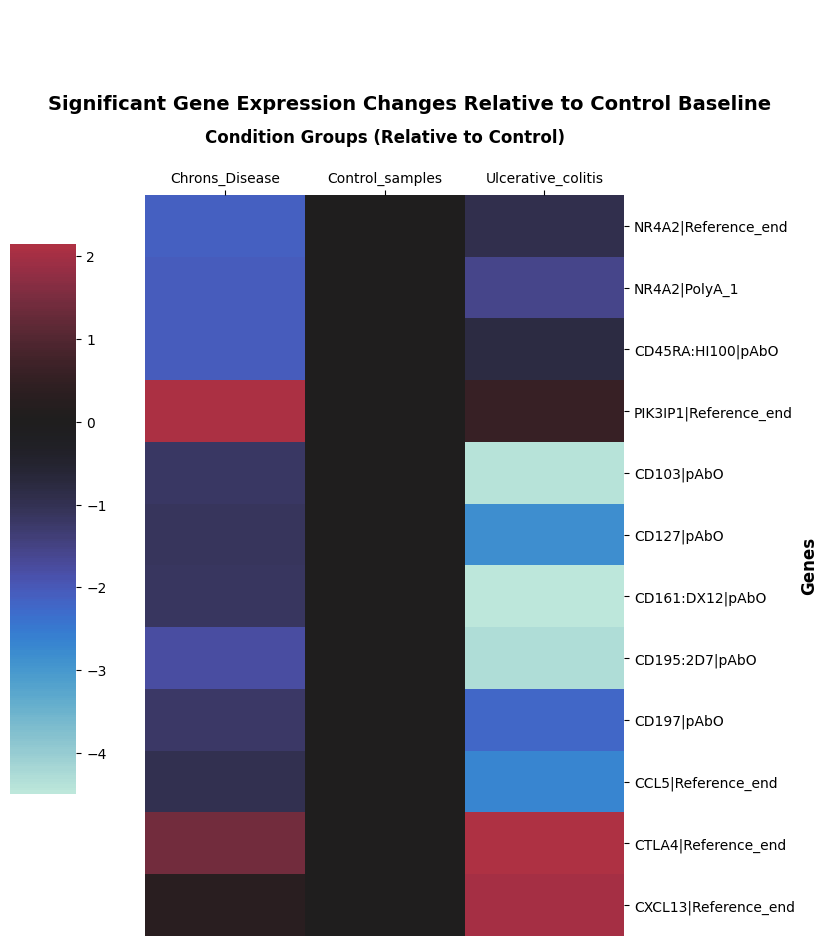

In [29]:
#same as up top except this one I can save the figure*** --> g.savefig("heatmap_gene_RdBu_expression.png", dpi=300, bbox_inches='tight')
#I made two seperate boxes since I was playing around with color schemes I did not want to save all the color schemes I tested out
#the top code I used to test which colors I liked then when I like them I changed out cmap param and ran code so it would sav as a png to my folder

#plot graph
g = sns.clustermap(fc_matrix.T,cmap='icefire',center=0,robust=True,row_cluster=False,col_cluster=False,figsize=(8, 10), yticklabels=True)

g.ax_heatmap.xaxis.tick_top()
#g.ax_heatmap.xaxis.set_label_position('top')
g.ax_heatmap.xaxis.set_label_coords(0.0, 1.09) 


#figure title: 'Gene Expression Changes Relative to Control Baseline, size, fontweight, and placement
g.fig.suptitle('Significant Gene Expression Changes Relative to Control Baseline', fontsize=14, fontweight='bold', y=.9)

#gene labeling font size and fontweight (vertically)
g.ax_heatmap.set_ylabel('Genes', fontsize=12, fontweight='bold')

#label what the group labels represent --> ondition Groups (Relative to Control)
g.ax_heatmap.set_xlabel('Condition Groups (Relative to Control)', fontsize=12, fontweight='bold')

#contols location of heatmap legend
g.ax_cbar.set_position([0.0, 0.20, 0.083, 0.55])

plt.show()

g.savefig("heatmap_gene_icefire_expression.png", dpi=300, bbox_inches='tight')

plt.show()

In [31]:
g.savefig("heatmap_gene_expression.png", dpi=300, bbox_inches='tight')

fig_uc.write_html("volcano_plot_colitis.html")